## Job Skills analysis

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/cleaned_postings.csv")
job_skills=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/jobs/job_skills.csv")
skills=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/mappings/skills.csv")


In [23]:
job_skills.head()

,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN


In [24]:
skills.head()

,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution


In [25]:
skill_data=job_skills.merge(skills,on="skill_abr",how="left")
skill_data["skill_name"].isnull().sum()

np.int64(0)

In [26]:
skills_df=df.merge(skill_data,on="job_id",how="left")
skills_df.head()

,job_id,company_name,title,description,location,views,formatted_work_type,applies,original_listed_time,remote_allowed,application_type,expiry,formatted_experience_level,listed_time,work_type,normalized_salary,clean_location,skill_abr,skill_name
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,ComplexOnsiteApply,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,MRKT,Marketing
1,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,ComplexOnsiteApply,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,SALE,Sales
2,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",1.0,Full-time,NaN,2024-04-11,Not specified,ComplexOnsiteApply,2024-05-11,Not specified,2024-04-11,FULL_TIME,83200.0,Fort Collins,HCPR,Health Care Provider
3,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,ComplexOnsiteApply,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MGMT,Management
4,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,ComplexOnsiteApply,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MNFC,Manufacturing


In [27]:
skills_df.shape

(206713, 19)

In [28]:
skills_df["skill_name"].isnull().sum()

np.int64(1739)

Each row should represent one job-skill pair — meaning if a job has 3 skills it will appear as 3 rows. 

In [29]:
missing=skills_df["skill_name"].isnull().sum()  ## missing vals in skill_name col
total=skills_df.shape[0]

In [30]:
coverage=((total-missing)/total)*100
coverage

np.float64(99.15873699283547)

In [31]:
skills_df=skills_df[skills_df["skill_name"].notna()]  ## dropping null skill name rows from main skills_df
skills_df.shape

(204974, 19)

In [37]:
skills_df["title"].value_counts().head(20)

title
Sales Manager                      1350
Assistant Store Manager             632
Project Manager                     630
Customer Service Representative     573
Salesperson                         492
Senior Accountant                   405
Account Executive                   399
Store Manager                       389
Executive Assistant                 371
Software Engineer                   369
Sales Associate                     367
Business Analyst                    344
Account Manager                     344
Staff Accountant                    342
Controller                          332
Sales Executive                     324
Administrative Assistant            316
Retail Sales Associate              302
Maintenance Technician              300
Business Development Manager        295
Name: count, dtype: int64

In [38]:
skills_df["title"].nunique()

70468

In [39]:
skills_df["title"]=skills_df["title"].str.title()
skills_df["title"]

0                        Marketing Coordinator
1                        Marketing Coordinator
2            Mental Health Therapist/Counselor
3                  Assitant Restaurant Manager
4                  Assitant Restaurant Manager
                          ...                 
206708    Account Executive, Oregon/Washington
206709    Account Executive, Oregon/Washington
206710            Business Development Manager
206711            Business Development Manager
206712       Marketing Social Media Specialist
Name: title, Length: 204974, dtype: object

In [40]:
skills_df["title"].nunique()

70468

In [41]:
skills_df["skill_name"].value_counts().head()

skill_name
Information Technology    25167
Sales                     21139
Management                20334
Manufacturing             17674
Health Care Provider      16608
Name: count, dtype: int64

In [42]:
skills_df.to_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/job_skills_clean.csv", index=False)

In [43]:
skills_df=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/job_skills_clean.csv")

## Functions:

In [44]:
def get_top_skills(df, n=20):
    """
    Returns top n most common skills from the dataset.
    
    Parameters:
        df: job_skills_clean dataframe
        n: number of top skills to return (default 20)
    
    Returns:
        pandas Series with skill names and counts
    """
    top_skills=df["skill_name"].value_counts().head(n)
    return top_skills

In [45]:
get_top_skills(skills_df, 20)

skill_name
Information Technology    25167
Sales                     21139
Management                20334
Manufacturing             17674
Health Care Provider      16608
Business Development      13278
Engineering               12479
Other                     12251
Finance                    7981
Marketing                  5385
Accounting/Auditing        4964
Administrative             4739
Customer Service           4141
Project Management         3813
Analyst                    3753
Research                   2918
Human Resources            2592
Consulting                 2231
Legal                      2208
Education                  2205
Name: count, dtype: int64

In [46]:
def get_role_skills(df,role):
    """
    Returns the top 10 most common skills associated with a given job role.

    Parameters:
        df : pandas DataFrame
            Skills dataframe containing job titles and skill names.
        role : str
            Job title to analyze.

    Returns:
        pandas Series
            Top 10 skills and their frequencies for the specified role.
    """

    roles_df=df[df["title"]==role]
    if roles_df.empty:
        return "role not found in dataset"
    skills=roles_df["skill_name"].value_counts().head(10)
    return skills

In [47]:
get_role_skills(skills_df, "Software Engineer")

skill_name
Engineering               158
Information Technology    129
Analyst                    34
Research                   32
Consulting                  3
Design                      2
Other                       2
Science                     2
Finance                     2
Project Management          1
Name: count, dtype: int64

In [95]:
def get_top_roles(df, n=10):
    """
    Returns top n most common job titles.

    Parameters:
        df : skills dataframe
        n : number of roles to return

    Returns:
        pandas Series
    """

    return df["title"].value_counts().head(n)

In [96]:
get_top_roles(skills_df, 10)

title
Sales Manager                      1350
Project Manager                     628
Customer Service Representative     466
Salesperson                         432
Senior Accountant                   403
Account Executive                   399
Software Engineer                   369
Executive Assistant                 366
Sales Associate                     365
Store Manager                       349
Name: count, dtype: int64

In [97]:
req_cols=skills_df[skills_df["skill_name"]=="Marketing"]
req_cols["normalized_salary"].mean().round(2)

np.float64(103571.07)

In [98]:
def get_salary_by_skill(df, skill):
    """
    Returns the average salary for jobs that require a specific skill.

    Parameters:
        df : pandas DataFrame
            Skills dataframe containing skill names and salary information.
        skill : str
            Skill name to analyze.

    Returns:
        float
            Average normalized salary for jobs requiring the specified skill.
    """
    
    req_df = df[df["skill_name"] == skill]
    
    if req_df.empty:                                                      ## checking is the skills exists in dataset
        return "Skill not found in dataset"
    
    salary = req_df["normalized_salary"].dropna()
    
    if len(salary) == 0:
        return "No salary data available for this skill"                   ## checking is salary data available for the skill
    return salary.mean().round(2)

In [99]:
get_salary_by_skill(skills_df, "Managemet")

'Skill not found in dataset'

In [100]:
def get_top_paying_skills(df, n=10):
    """
    Returns the top n skills ranked by average salary.

    Parameters:
        df : pandas DataFrame
            Skills dataframe containing skill names and salary information.
        n : int, optional
            Number of top-paying skills to return. Default is 10.

    Returns:
        pandas Series
            Skill names and their average salaries, sorted in descending order.
    """
    salary_df = df.dropna(subset=["normalized_salary"])
    grp = salary_df.groupby("skill_name")
    salary = grp["normalized_salary"].mean()
    return salary.sort_values(ascending=False).head(n).round(2)

In [101]:
get_top_paying_skills(skills_df, 10)

skill_name
Product Management        145857.46
Legal                     134897.22
Strategy/Planning         131787.37
Engineering               126718.62
Consulting                123114.81
Project Management        118760.90
Information Technology    116566.92
Science                   115131.43
Research                  111828.03
Finance                   104309.69
Name: normalized_salary, dtype: float64

In [102]:
def skill_gap(user_skills, target_role, df):
    """
    Compares a user's skills with the skills most commonly
    required for a target job role.
    Parameters:
        user_skills : list
            List of skills possessed by the user.
        target_role : str
            Job role to compare against.
        df : pandas DataFrame
            Skills dataframe containing job titles and skill names.
    Returns:
        dict
            Dictionary containing:
            - 'have': skills the user already possesses
            - 'missing': skills required for the role but not possessed by the user
    """
    req_role_skills = get_role_skills(df, target_role)
    if isinstance(req_role_skills, str):                     ##get_role_skills() returns a string "Role not found in dataset" when role doesn't exist. If that happens, .index will break
        return req_role_skills
    
    req_role_skills = [s.lower() for s in req_role_skills.index]
    user_skills = [s.lower() for s in user_skills]
    
    have = []
    missing = []
    for skill in req_role_skills:
        if skill in user_skills:
            have.append(skill)
        else:
            missing.append(skill)
    
    return {"have": have, "missing": missing}
        

In [103]:
my_skills = ["Management", "Sales", "Finance"]

skill_gap(
    my_skills,
    "Software Engineer",
    skills_df
)

{'have': ['finance'],
 'missing': ['engineering',
  'information technology',
  'analyst',
  'research',
  'consulting',
  'design',
  'other',
  'science',
  'project management']}

In [104]:
# x=(get_role_skills(skills_df,"Software Engineer").index)

In [105]:
# my_skills = ["Management", "Sales", "Finance",'Science']

# have=[]
# missing=[]
# for i in x:
#     if i in my_skills:
#         have.append(i)
#     else:
#         missing.append(i)

# print(have)
# print(missing)
        

In [106]:
def get_salary_by_role(df, role):
    """
    Returns the average salary for a specific job role.

    Parameters:
        df : pandas DataFrame
            Dataframe containing job postings and salary information.
        role : str
            Job role to analyze.

    Returns:
        float or str
            Average salary for the role or an error message.
    """

    role_df = df[df["title"].str.lower() == role.lower()]

    if role_df.empty:
        return "Role not found in dataset"

    salary = role_df["normalized_salary"].dropna()

    if salary.empty:
        return "No salary data available for this role"

    return salary.mean().round(2)

In [107]:
get_salary_by_role(skills_df, "Software Engineer")

np.float64(168593.29)

In [108]:
def get_top_locations(df, n=10):
    """
    Returns the top n locations by job posting count.

    Parameters:
        df : pandas DataFrame
            Dataframe containing location information.
        n : int, optional
            Number of locations to return.

    Returns:
        pandas Series
            Locations and their posting counts.
    """

    location_df = df[
        (df["clean_location"] != "United States")
        & (df["clean_location"] != "")
    ]

    return location_df["clean_location"].value_counts().head(n)

In [109]:
get_top_locations(df, 10)

clean_location
New York       3376
Chicago        1829
Houston        1768
Dallas         1387
Atlanta        1365
Austin         1322
Boston         1196
Washington     1114
Los Angeles    1092
Charlotte      1082
Name: count, dtype: int64

In [110]:
def get_remote_percentage(df):
    """
    Returns the percentage of remote jobs in the dataset.

    Parameters:
        df : pandas DataFrame
            Dataframe containing remote job information.

    Returns:
        float
            Percentage of remote jobs.
    """

    remote_jobs = (
        df["remote_allowed"] == "Yes"
    ).sum()

    total_jobs = len(df)

    percentage = (
        remote_jobs / total_jobs
    ) * 100

    return round(percentage, 2)

In [111]:
get_remote_percentage(df)

np.float64(12.29)

## creating visualization using functions:

### (1) Top 20 Skills Bar Chart:

In [112]:
top_skills=get_top_skills(skills_df, 20)

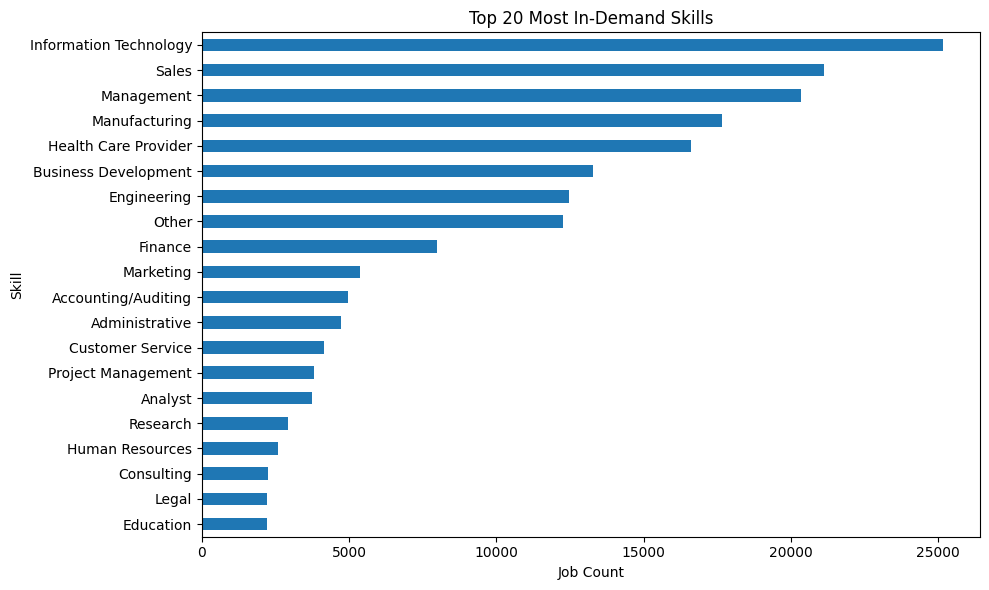

In [113]:
plt.figure(figsize=(10,6))

top_skills.sort_values().plot(kind="barh")
plt.title("Top 20 Most In-Demand Skills")
plt.xlabel("Job Count")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

In [114]:
plt.savefig("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/reports/top_20_skills.png")

<Figure size 640x480 with 0 Axes>

## (2)Skills by Experience Level:

In [115]:
experience_levels=levels = ["Entry level", "Mid-Senior level", "Associate", "Director", "Internship", "Executive"]

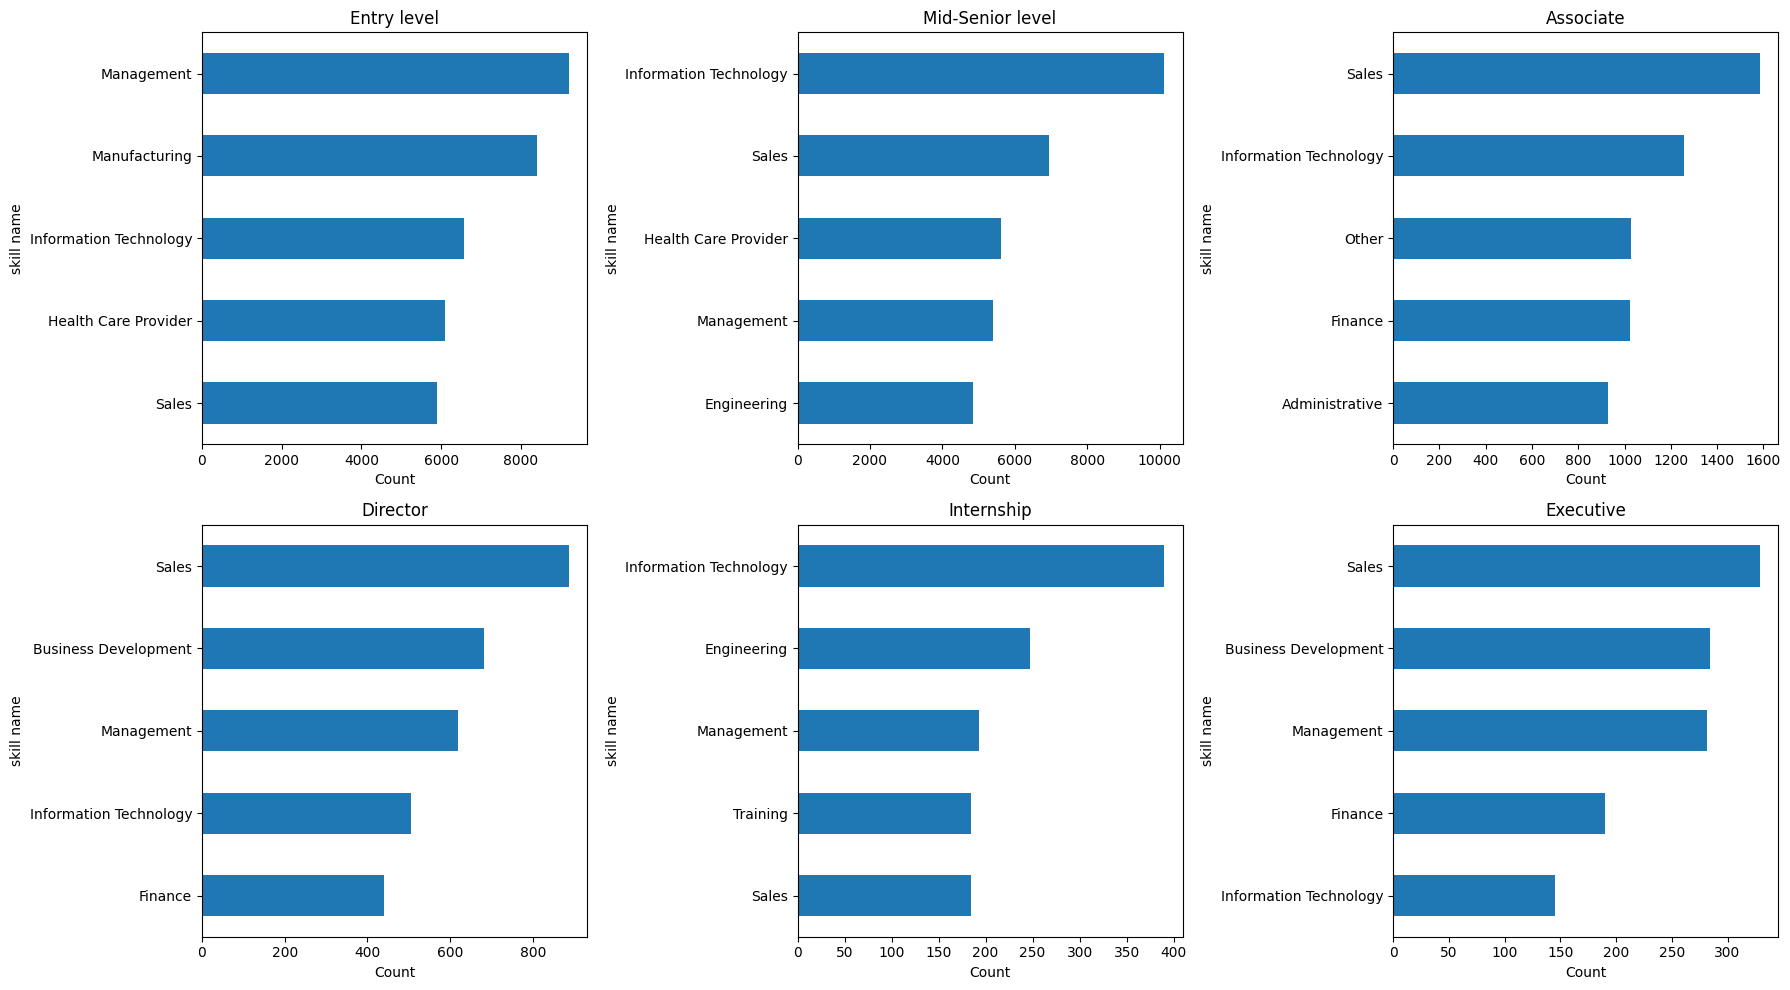

In [116]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes=axes.flatten()

for i,level in enumerate(experience_levels):
    level_df=skills_df[skills_df["formatted_experience_level"]==level]
    top_skills=get_top_skills(level_df,5)

    top_skills.sort_values().plot(kind="barh",ax=axes[i])
    axes[i].set_title(level)
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("skill name")
plt.tight_layout()
plt.show()
    
    

In [117]:
plt.savefig("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/reports/Skills_by_experience_level.png")

<Figure size 640x480 with 0 Axes>

## (3) skill demand vs salary:

In [118]:
skills_demand=skills_df["skill_name"].value_counts()
skills_demand

skill_name
Information Technology    25167
Sales                     21139
Management                20334
Manufacturing             17674
Health Care Provider      16608
Business Development      13278
Engineering               12479
Other                     12251
Finance                    7981
Marketing                  5385
Accounting/Auditing        4964
Administrative             4739
Customer Service           4141
Project Management         3813
Analyst                    3753
Research                   2918
Human Resources            2592
Consulting                 2231
Legal                      2208
Education                  2205
Design                     2190
Training                   2157
General Business           1922
Quality Assurance          1748
Art/Creative               1625
Writing/Editing            1418
Product Management         1309
Public Relations           1255
Supply Chain               1163
Strategy/Planning          1153
Science                     7

In [119]:
grp=skills_df.groupby("skill_name")
salary=grp["normalized_salary"].mean().round(2)
salary

skill_name
Accounting/Auditing        99076.02
Administrative             71523.95
Advertising               103472.57
Analyst                   103656.06
Art/Creative               94421.23
Business Development       94318.29
Consulting                123114.81
Customer Service           62214.22
Design                    101196.58
Distribution               74511.43
Education                  70358.89
Engineering               126718.62
Finance                   104309.69
General Business           95008.73
Health Care Provider       99844.30
Human Resources            97258.83
Information Technology    116566.92
Legal                     134897.22
Management                 75630.89
Manufacturing              68610.29
Marketing                 103571.07
Other                      76600.93
Product Management        145857.46
Production                 79894.97
Project Management        118760.90
Public Relations           93895.68
Purchasing                 95136.67
Quality Assurance

In [120]:
skill_stats=pd.DataFrame({"frequency":skills_demand,"avg_salary":salary})
skill_stats.head()

,frequency,avg_salary
skill_name,,
Accounting/Auditing,4964,99076.02
Administrative,4739,71523.95
Advertising,648,103472.57
Analyst,3753,103656.06
Art/Creative,1625,94421.23


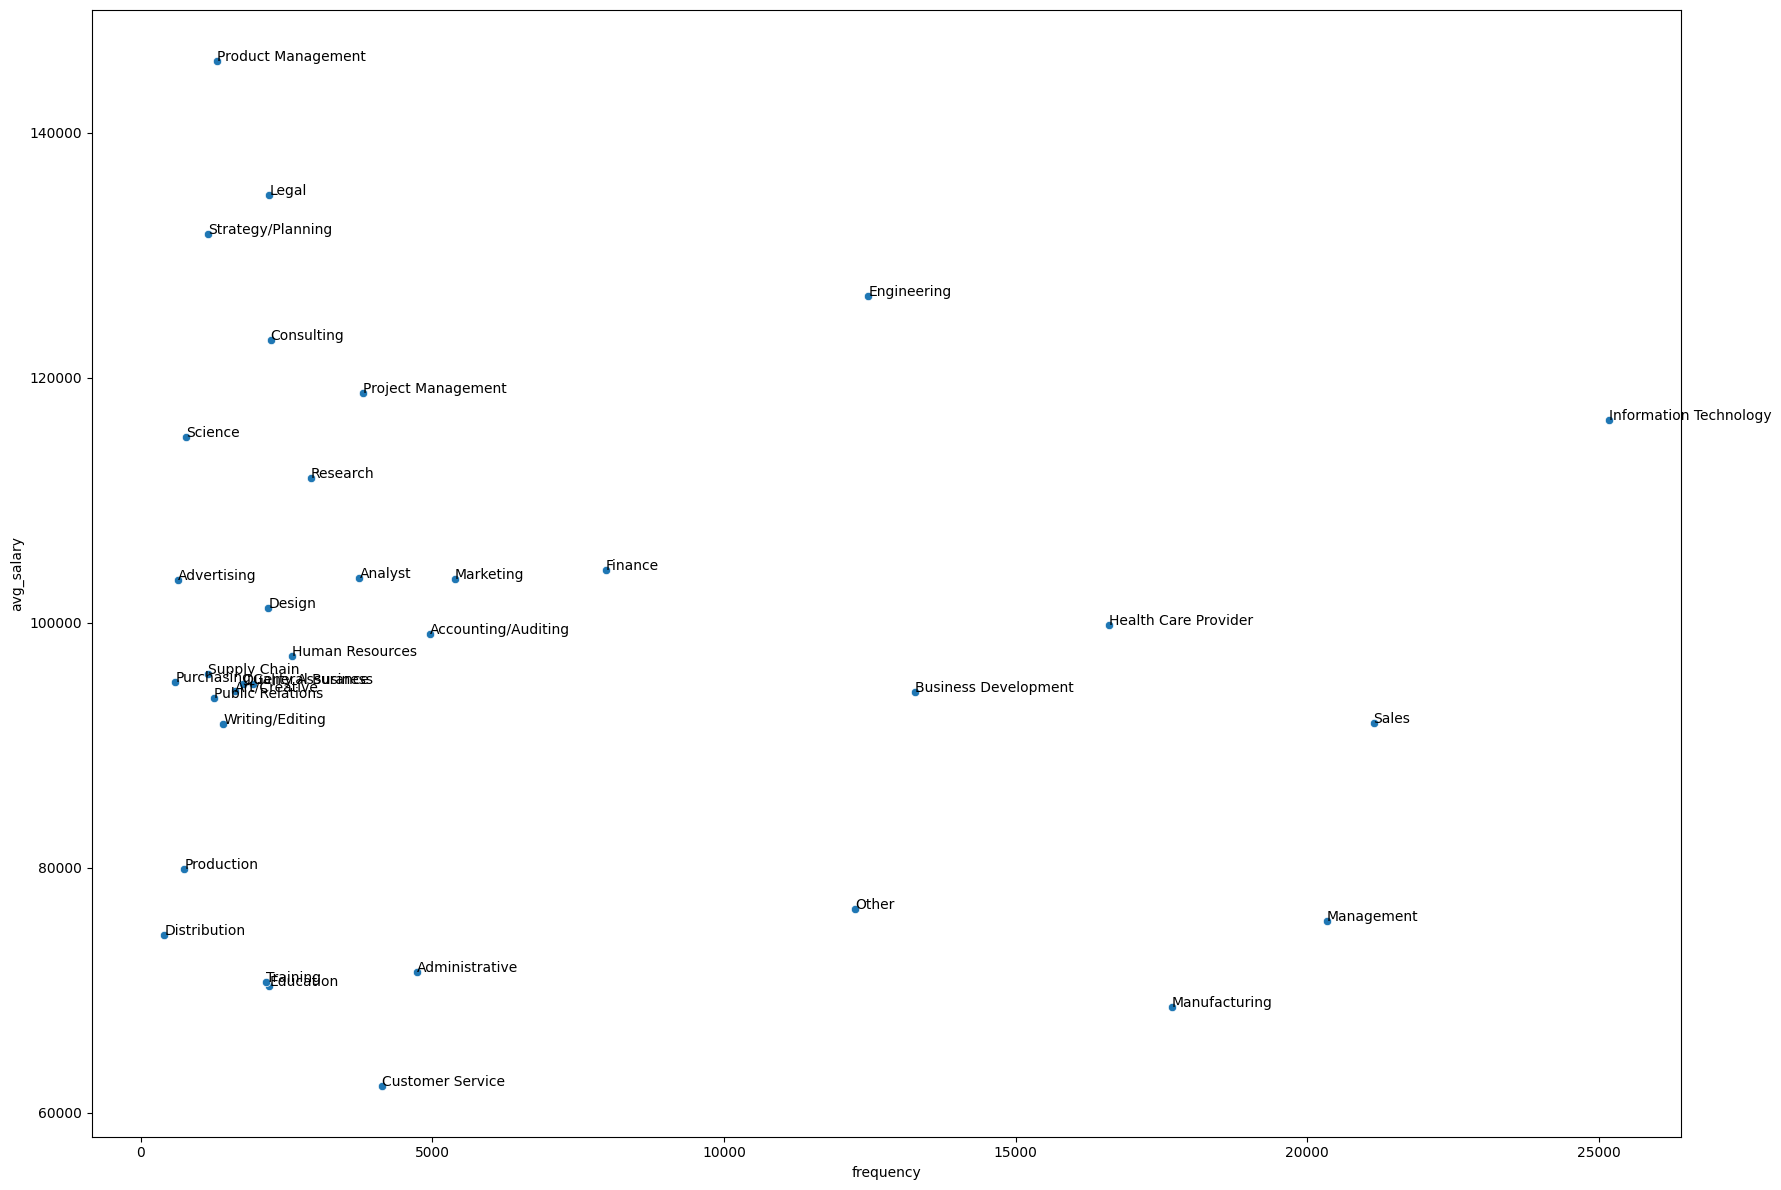

In [121]:
plt.figure(figsize=(18,12))
sns.scatterplot(data=skill_stats,x="frequency",y="avg_salary")
for skill in skill_stats.index:

    plt.annotate(
        skill,
        (skill_stats.loc[skill, "frequency"],skill_stats.loc[skill, "avg_salary"]),
    )
plt.tight_layout()
plt.show()

In [122]:
plt.savefig("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/reports/skills_demand_by_salary.png")

<Figure size 640x480 with 0 Axes>

## (4) Role to Skills Mapping:

In [123]:
top_roles=get_top_roles(df,20)
top_roles.index

Index(['Sales Manager', 'Customer Service Representative', 'Project Manager',
       'Administrative Assistant', 'Senior Accountant', 'Executive Assistant',
       'Salesperson', 'Registered Nurse', 'Receptionist', 'Staff Accountant',
       'Account Executive', 'Retail Sales Associate', 'Sales Associate',
       'Software Engineer', 'Controller', 'Account Manager', 'Store Manager',
       'Assistant Manager', 'ASSISTANT STORE MANAGER',
       'Senior Software Engineer'],
      dtype='object', name='title')

In [124]:
role_skills_map = {}
for role in top_roles.index:
    top_skills=(get_role_skills(skills_df,role)).index
    role_skills_map[role]=top_skills.tolist()

role_skills_map

{'Sales Manager': ['Sales',
  'Business Development',
  'Management',
  'Training',
  'Manufacturing',
  'Distribution',
  'Customer Service',
  'Strategy/Planning',
  'Finance',
  'General Business'],
 'Customer Service Representative': ['Other',
  'Customer Service',
  'Marketing',
  'Management',
  'Administrative',
  'Sales',
  'General Business',
  'Public Relations',
  'Accounting/Auditing',
  'Business Development'],
 'Project Manager': ['Project Management',
  'Information Technology',
  'Management',
  'Engineering',
  'Product Management',
  'Business Development',
  'Manufacturing',
  'Other',
  'Administrative',
  'Consulting'],
 'Administrative Assistant': ['Administrative',
  'Customer Service',
  'General Business',
  'Human Resources',
  'Project Management',
  'Other',
  'Analyst',
  'Consulting',
  'Accounting/Auditing',
  'Marketing'],
 'Senior Accountant': ['Accounting/Auditing',
  'Finance',
  'Analyst',
  'Administrative',
  'General Business',
  'Other',
  'Manuf

In [125]:
import json

with open("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/role_skills_map.json", "w") as f:
    json.dump(role_skills_map, f, indent=4)

## (5) Role vs average salary chart

In [126]:
top_roles=(get_top_roles(df,20))

temp={}
for i in top_roles.index:
    salary=get_salary_by_role(df,i)
    if isinstance(salary,str):
        continue
    else:
        temp[i]=salary

s=pd.Series(temp)

# Skills by Industry analysis:

In [4]:
skills_df=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/job_skills_clean.csv")
industries_id=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/jobs/job_industries.csv")
industries_mapping=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/mappings/industries.csv")

In [128]:
industries_id.head()

,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41
3,3887467939,82
4,3887467939,80


In [129]:
industries_mapping.head()

,industry_id,industry_name
0,1,Defense and Space Manufacturing
1,3,Computer Hardware Manufacturing
2,4,Software Development
3,5,Computer Networking Products
4,6,"Technology, Information and Internet"


In [130]:
industries_data=industries_id.merge(industries_mapping,on="industry_id",how="left")
industries_data.head()

,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


In [131]:
skills_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204974 entries, 0 to 204973
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      204974 non-null  int64  
 1   company_name                202374 non-null  object 
 2   title                       204974 non-null  object 
 3   description                 204963 non-null  object 
 4   location                    204974 non-null  object 
 5   views                       202142 non-null  float64
 6   formatted_work_type         204974 non-null  object 
 7   applies                     39531 non-null   float64
 8   original_listed_time        204974 non-null  object 
 9   remote_allowed              204974 non-null  object 
 10  application_type            204974 non-null  object 
 11  expiry                      204974 non-null  object 
 12  formatted_experience_level  204974 non-null  object 
 13  listed_time   

In [132]:
industries_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164808 entries, 0 to 164807
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   job_id         164808 non-null  int64 
 1   industry_id    164808 non-null  int64 
 2   industry_name  164708 non-null  object
dtypes: int64(2), object(1)
memory usage: 3.8+ MB


In [133]:
skills_industries_data=skills_df.merge(industries_data,on="job_id",how="left")
skills_industries_data.head()

,job_id,company_name,title,description,location,views,formatted_work_type,applies,original_listed_time,remote_allowed,...,expiry,formatted_experience_level,listed_time,work_type,normalized_salary,clean_location,skill_abr,skill_name,industry_id,industry_name
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,...,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,MRKT,Marketing,44.0,Real Estate
1,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,...,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,SALE,Sales,44.0,Real Estate
2,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",1.0,Full-time,NaN,2024-04-11,Not specified,...,2024-05-11,Not specified,2024-04-11,FULL_TIME,83200.0,Fort Collins,HCPR,Health Care Provider,NaN,NaN
3,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,...,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MGMT,Management,32.0,Restaurants
4,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,...,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MNFC,Manufacturing,32.0,Restaurants


In [134]:
top_industries=skills_industries_data["industry_name"].value_counts().head(10)

In [135]:
industries_df=skills_industries_data[skills_industries_data["industry_name"].isin(top_industries.index)]

In [136]:
industries_df.head()

,job_id,company_name,title,description,location,views,formatted_work_type,applies,original_listed_time,remote_allowed,...,expiry,formatted_experience_level,listed_time,work_type,normalized_salary,clean_location,skill_abr,skill_name,industry_id,industry_name
15,1218575,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service ...","Omaha, NE",3.0,Full-time,NaN,2024-04-05,Not specified,...,2024-05-05,Not specified,2024-04-05,FULL_TIME,NaN,Omaha,HCPR,Health Care Provider,14.0,Hospitals and Health Care
20,69333422,Staffing Theory,Senior Product Marketing Manager,A leading pharmaceutical company committed to ...,United States,2.0,Full-time,NaN,2024-04-19,Yes,...,2024-10-16,Not specified,2024-04-19,FULL_TIME,NaN,United States,MRKT,Marketing,104.0,Staffing and Recruiting
21,69333422,Staffing Theory,Senior Product Marketing Manager,A leading pharmaceutical company committed to ...,United States,2.0,Full-time,NaN,2024-04-19,Yes,...,2024-10-16,Not specified,2024-04-19,FULL_TIME,NaN,United States,SALE,Sales,104.0,Staffing and Recruiting
39,133130219,NaN,Software Engineer,"Education Bachelor's degree in software, math,...",Los Angeles Metropolitan Area,1.0,Full-time,NaN,2024-04-19,Not specified,...,2024-05-19,Not specified,2024-04-19,FULL_TIME,NaN,Los Angeles Metropolitan Area,ENG,Engineering,96.0,IT Services and IT Consulting
40,133130219,NaN,Software Engineer,"Education Bachelor's degree in software, math,...",Los Angeles Metropolitan Area,1.0,Full-time,NaN,2024-04-19,Not specified,...,2024-05-19,Not specified,2024-04-19,FULL_TIME,NaN,Los Angeles Metropolitan Area,IT,Information Technology,96.0,IT Services and IT Consulting


In [137]:
heatmap_data=pd.crosstab(industries_df["industry_name"],industries_df["skill_name"])
heatmap_data

skill_name,Accounting/Auditing,Administrative,Advertising,Analyst,Art/Creative,Business Development,Consulting,Customer Service,Design,Distribution,...,Public Relations,Purchasing,Quality Assurance,Research,Sales,Science,Strategy/Planning,Supply Chain,Training,Writing/Editing
industry_name,,,,,,,,,,,,,,,,,,,,,
Banking,175,96,0,162,11,285,146,65,16,0,...,9,6,25,28,1272,1,24,7,8,15
Construction,212,124,4,42,64,294,93,86,142,8,...,19,18,72,18,386,8,67,22,24,28
Financial Services,626,461,11,406,42,1506,311,386,62,2,...,44,21,55,119,2896,5,90,21,99,50
Hospitals and Health Care,234,689,14,499,36,456,217,142,35,16,...,37,24,83,469,662,63,55,34,136,41
IT Services and IT Consulting,162,199,53,363,164,926,533,122,207,3,...,82,46,134,184,1336,21,104,57,51,91
Manufacturing,306,122,10,115,35,415,24,313,80,36,...,28,65,132,42,842,15,73,143,52,32
Pharmaceutical Manufacturing,71,83,34,201,21,285,86,81,31,23,...,43,11,169,353,359,294,62,83,49,31
Retail,103,238,30,72,181,3278,21,1798,182,88,...,55,30,32,19,4603,3,45,70,142,37
Software Development,141,73,28,392,95,621,167,75,131,38,...,53,21,51,335,925,23,55,62,30,116


In [138]:
### we neeed only top 5 skills for each industry

In [139]:
top_skills=industries_df["skill_name"].value_counts().head(5).index
top_skills

Index(['Information Technology', 'Health Care Provider', 'Sales',
       'Business Development', 'Management'],
      dtype='object', name='skill_name')

In [140]:
heatmap_data=heatmap_data[top_skills]
heatmap_data

skill_name,Information Technology,Health Care Provider,Sales,Business Development,Management
industry_name,,,,,
Banking,667,0,1272,285,119
Construction,580,1,386,294,1075
Financial Services,1847,27,2896,1506,409
Hospitals and Health Care,1446,11269,662,456,1190
IT Services and IT Consulting,5684,171,1336,926,628
Manufacturing,399,12,842,415,739
Pharmaceutical Manufacturing,406,225,359,285,211
Retail,666,191,4603,3278,2383
Software Development,2133,23,925,621,240


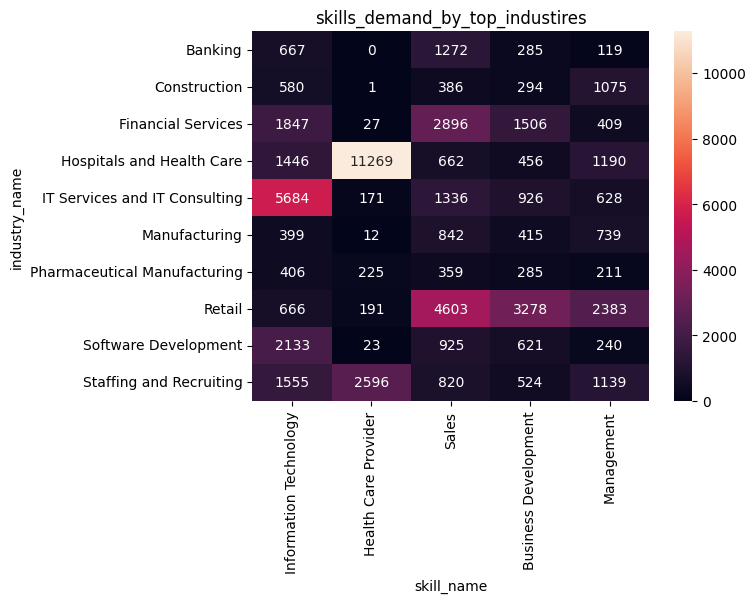

In [141]:
sns.heatmap(heatmap_data,annot=True,fmt=".0f")
plt.title("skills_demand_by_top_industires")
plt.show()

In [142]:
plt.savefig("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/reports/skills_demand_by_industries.png")

<Figure size 640x480 with 0 Axes>

## Skill popularity over time:

In [143]:
skills_df["listed_time"]=pd.to_datetime(skills_df["listed_time"])
skills_df["listed_time"]

0        2024-04-17
1        2024-04-17
2        2024-04-11
3        2024-04-16
4        2024-04-16
            ...    
204969   2024-04-20
204970   2024-04-20
204971   2024-04-20
204972   2024-04-20
204973   2024-04-20
Name: listed_time, Length: 204974, dtype: datetime64[ns]

In [144]:
skills_df["month"]=skills_df["listed_time"].dt.to_period("M")
skills_df.head()

,job_id,company_name,title,description,location,views,formatted_work_type,applies,original_listed_time,remote_allowed,application_type,expiry,formatted_experience_level,listed_time,work_type,normalized_salary,clean_location,skill_abr,skill_name,month
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,ComplexOnsiteApply,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,MRKT,Marketing,2024-04
1,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,ComplexOnsiteApply,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,SALE,Sales,2024-04
2,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",1.0,Full-time,NaN,2024-04-11,Not specified,ComplexOnsiteApply,2024-05-11,Not specified,2024-04-11,FULL_TIME,83200.0,Fort Collins,HCPR,Health Care Provider,2024-04
3,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,ComplexOnsiteApply,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MGMT,Management,2024-04
4,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,ComplexOnsiteApply,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MNFC,Manufacturing,2024-04


In [145]:
top_skills = get_top_skills(skills_df, 5).index
top_skills

Index(['Information Technology', 'Sales', 'Management', 'Manufacturing',
       'Health Care Provider'],
      dtype='object', name='skill_name')

In [146]:
skills_df=skills_df[skills_df["skill_name"].isin(top_skills)]
grp=skills_df.groupby(["skill_name","month"]).size()
grp

skill_name              month  
Health Care Provider    2024-04    16608
Information Technology  2024-04    25167
Management              2024-03        1
                        2024-04    20333
Manufacturing           2024-03        1
                        2024-04    17673
Sales                   2024-04    21139
dtype: int64

## Universal vs niche skills:

In [147]:
skills_df=pd.read_csv("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/data/job_skills_clean.csv")

In [10]:
grp=skills_df.groupby("skill_name")
grp["title"].nunique()

skill_name
Accounting/Auditing        2394
Administrative             2941
Advertising                 432
Analyst                    2632
Art/Creative               1190
Business Development       6646
Consulting                 1694
Customer Service           2067
Design                     1617
Distribution                277
Education                  1631
Engineering                7910
Finance                    4802
General Business           1132
Health Care Provider       9698
Human Resources            1614
Information Technology    16817
Legal                      1327
Management                12242
Manufacturing             10586
Marketing                  3318
Other                      8401
Product Management          916
Production                  605
Project Management         2484
Public Relations            941
Purchasing                  388
Quality Assurance          1163
Research                   2009
Sales                     11311
Science                     6

"All skill categories in this dataset are universal — each appears across multiple job roles. This is because LinkedIn uses broad skill categories rather than specific technologies. More granular skill analysis would require NLP on job descriptions."

## Salary distribution by skill chart:

In [149]:
top_skills=get_top_skills(skills_df,10)
top_skills

skill_name
Information Technology    25167
Sales                     21139
Management                20334
Manufacturing             17674
Health Care Provider      16608
Business Development      13278
Engineering               12479
Other                     12251
Finance                    7981
Marketing                  5385
Name: count, dtype: int64

In [150]:
top_skills_df=skills_df[skills_df["skill_name"].isin(top_skills.index)]
top_skills_df = top_skills_df[top_skills_df["normalized_salary"].notna()]

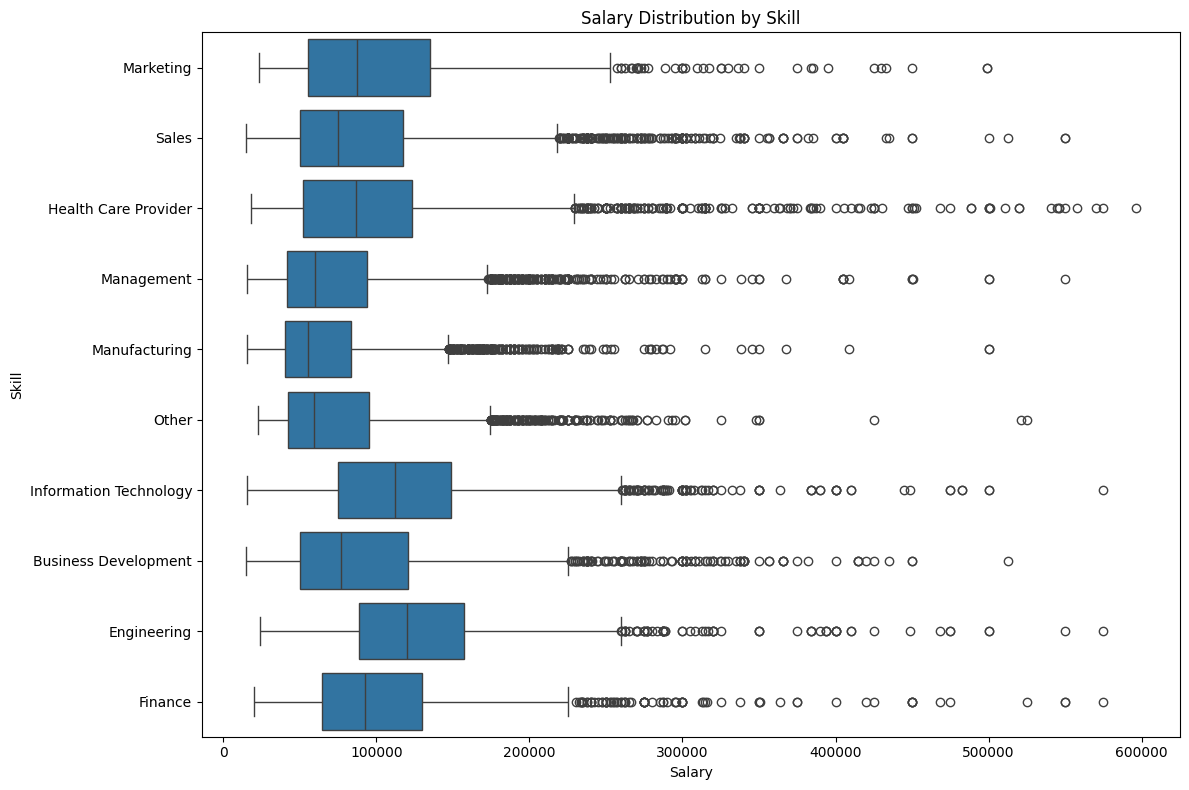

In [151]:
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=top_skills_df,
    x="normalized_salary",
    y="skill_name"
)

plt.title("Salary Distribution by Skill")
plt.xlabel("Salary")
plt.ylabel("Skill")
plt.tight_layout()

plt.savefig("C:/Users/punit/OneDrive/Documents/Job_market_intelligence_project/reports/skills_distribution_by_skill.png")
plt.show()

## Salary Percentile Analysis:

In [152]:
top_skills=get_top_skills(skills_df,10)
grp = top_skills_df.groupby("skill_name")

In [153]:
p25=grp["normalized_salary"].quantile(0.25)
median=grp["normalized_salary"].median()
p75=grp["normalized_salary"].quantile(0.75)

In [154]:
p25

skill_name
Business Development      50000.0
Engineering               88400.0
Finance                   64307.5
Health Care Provider      52000.0
Information Technology    75000.0
Management                41600.0
Manufacturing             40560.0
Marketing                 55120.0
Other                     42151.2
Sales                     49920.0
Name: normalized_salary, dtype: float64

In [155]:
salary_stats = pd.DataFrame({"p25": p25,"median": median,"p75": p75})
salary_stats

,p25,median,p75
skill_name,,,
Business Development,50000.0,77000.0,120502.400
Engineering,88400.0,120000.0,157000.000
Finance,64307.5,92500.0,130000.000
Health Care Provider,52000.0,87000.0,123024.000
Information Technology,75000.0,112500.5,149033.750
Management,41600.0,59670.0,94000.000
Manufacturing,40560.0,55120.0,83200.000
Marketing,55120.0,87360.0,135200.000
Other,42151.2,59500.0,94968.750


In [156]:
def get_salary_stats(df,skill):
    """
    Returns detailed salary statistics for a specific skill.
    
    Parameters:
        df : pandas.DataFrame
            Skills dataframe containing skill names and salary information.
        skill : str
            Skill name to analyze.
    
    Returns:
        dict
            Dictionary containing:
            - mean: average salary
            - median: median salary
            - p25: 25th percentile salary
            - p75: 75th percentile salary
            - count: number of jobs with salary data
    
            Returns an error message if the skill is not found
            or if no salary data is available.
    """
    skill_data=df[df["skill_name"].str.lower()==skill.lower()]
    if len(skill_data)==0:
        return "Skill not found"
        
    salary = skill_data["normalized_salary"].dropna()
    if len(salary) == 0:
        return "No salary data available for this skill"

    p25=salary.quantile(0.25).round(2)
    median = round(salary.median(), 2)
    p75=salary.quantile(0.75).round(2)
    mean=salary.mean().round(2)
    count=salary.count()

    salary_stats = {
    "mean": mean,
    "median": median,
    "p25": p25,
    "p75": p75,
    "count": count}
    
    return salary_stats

In [157]:
get_salary_stats(skills_df,"Sales")

{'mean': np.float64(91849.51),
 'median': 75000.0,
 'p25': np.float64(49920.0),
 'p75': np.float64(117702.72),
 'count': np.int64(5594)}

## Test Block:

In [160]:
print(get_top_skills(skills_df, 5))
print(get_top_roles(skills_df, 5))
print(get_salary_by_skill(skills_df, "Sales"))
print(get_salary_stats(skills_df, "Sales"))
print(get_top_locations(skills_df, 5))
print(get_remote_percentage(skills_df))

skill_name
Information Technology    25167
Sales                     21139
Management                20334
Manufacturing             17674
Health Care Provider      16608
Name: count, dtype: int64
title
Sales Manager                      1350
Project Manager                     628
Customer Service Representative     466
Salesperson                         432
Senior Accountant                   403
Name: count, dtype: int64
91849.51
{'mean': np.float64(91849.51), 'median': 75000.0, 'p25': np.float64(49920.0), 'p75': np.float64(117702.72), 'count': np.int64(5594)}
clean_location
New York    5781
Houston     3050
Chicago     3019
Atlanta     2405
Dallas      2315
Name: count, dtype: int64
12.75
